# Finding grid cells that could be called "coastal" by having a non-zero amount of land (lsm > 0.1) and also at least one neighbor that is fully water (lsm = 0)

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds = xr.open_dataset(file_path)
ds

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

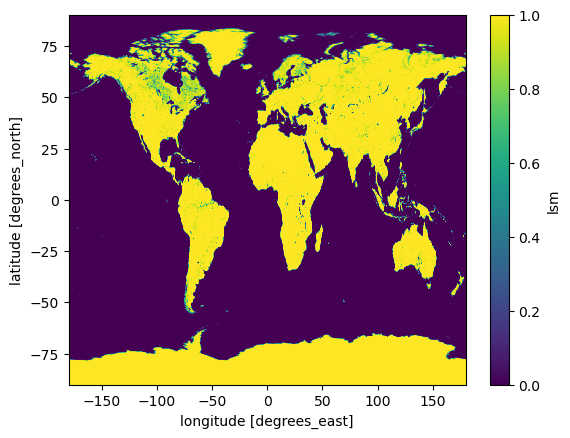

In [62]:
ds.lsm.plot()

# Try to use crafty indexing so I don't have to loop to check all the neighbors of a cell

In [31]:
([float(ds.lsm.lat[0]), float(ds.lsm.lat[-1])])

[90.0, -90.0]

In [30]:
res = 0.25
ds_coastal = ds.where((ds.lsm > 0.1) & # must have some land in the currrent cell
                      (ds.lsm.sel(lat=slice(np.min([float((ds.lsm.lat+res).values), float(ds.lsm.lat[0])]),
                                            np.max([float((ds.lsm.lat-res).values), float(ds.lsm.lat[-1])])), 
                                  lon=slice(np.min([float((ds.lsm.lon+res).values), float(ds.lsm.lon[0])]),
                                            np.max([float((ds.lsm.lon+res).values), float(ds.lsm.lon[-1])]))).isin([0,0]).sum() > 1) # at least one neighbor has lsm=0
                     )

ds_coastal

TypeError: only length-1 arrays can be converted to Python scalars

# Guess I'll have to write a loop

In [19]:
# testing isin()
da = xr.DataArray([0.0, 1, 2, 3, 4, 5], dims=["x"])
if (da.isin([0]).sum() >= 1):
    print("YES")

In [ ]:
%%time

# takes 4 min 

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds.lat.values[:num_lat]
loop_lons = ds.lon.values[:num_lon]

# empty data arrays for coastal boolean
coastal = xr.DataArray(np.full((num_lat,num_lon), False, dtype=bool), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])

# add attributes
coastal.attrs["long_name"] = "Boolean value for whether the cell has at least one all water neighbor"
coastal.attrs["units"] = "true/false"

# resolution of grid
res = 0.25

# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # is the current cell at least partially land?
        if (ds.lsm.sel(lat=input_lat, lon=input_lon) > 0.5): 
        
            # check neighborhood and handle boundaries
            # if one cell in the neighborhood has value 0 then it has a water neighbor
            if ((ds.lsm.sel(lat=slice(np.min([test_lat+res, float(ds.lsm.lat[0])]),
                                      np.max([test_lat-res, float(ds.lsm.lat[-1])])), 
                            lon=slice(np.max([lest_lon-res, float(ds.lsm.lon[0])]),
                                      np.min([lest_lon+res, float(ds.lsm.lon[-1])]))) < 0.2).sum() >= 1):
                # then it is a coastal cell
                coastal.loc[input_lat, input_lon] = True
            else:
                coastal.loc[input_lat, input_lon] = False

        
# results dataset
results_ds = xr.Dataset(data_vars={'Coastal':coastal})

# see results
results_ds

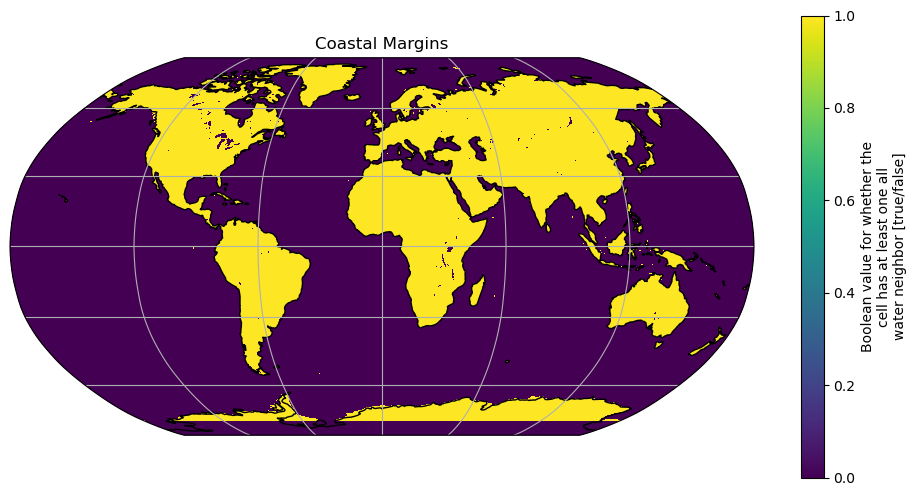

In [122]:

fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.Coastal.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    #vmin=-2,
    #vmax=2, 
    #cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Coastal Margins")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

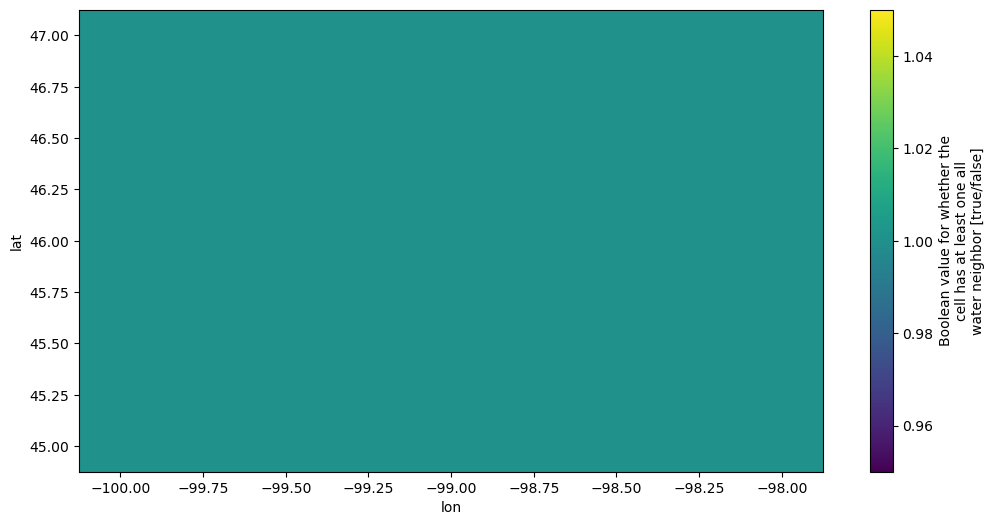

In [125]:
plt.figure(figsize=(12,6))
results_ds.Coastal.sel(lat=slice(47,45),lon=slice(-100,-98)).plot()

In [150]:
test_lat = 46
lest_lon = -99

# is the current cell at least partially land?
if (bool(ds.lsm.sel(lat=test_lat, lon=lest_lon) > 0.3)): 

    # check neighborhood and handle boundaries
    # if one cell in the neighborhood has value 0 then it has a water neighbor
    if ((ds.lsm.sel(lat=slice(np.min([test_lat+res, float(ds.lsm.lat[0])]),
                             np.max([test_lat-res, float(ds.lsm.lat[-1])])), 
                   lon=slice(np.max([lest_lon-res, float(ds.lsm.lon[0])]),
                             np.min([lest_lon+res, float(ds.lsm.lon[-1])]))) < 0.2).sum() >= 1):
        # then it is a coastal cell
        print("True")
    else:
        print("False")

False


In [136]:
ds.lsm.sel(lat=slice(47,45),lon=slice(-100,-98))

<xarray.DataArray 'lsm' (lat: 9, lon: 9)> Size: 648B
array([[0.938016, 0.894923, 0.901363, 0.94151 , 0.952604, 0.962034, 0.965422,
        0.967009, 0.969038],
       [0.914471, 0.934644, 0.948301, 0.955976, 0.97531 , 0.99826 , 0.985885,
        0.985519, 0.993194],
       [0.983077, 0.961867, 0.951292, 0.947294, 0.953336, 0.984237, 0.996765,
        0.990554, 0.993881],
       [0.988464, 0.994934, 0.950224, 0.932874, 0.946149, 0.981582, 0.995605,
        0.987838, 0.982711],
       [0.985244, 0.989151, 0.949735, 0.938092, 0.968153, 0.979873, 0.988464,
        0.980758, 0.990875],
       [0.980163, 0.98207 , 0.968535, 0.973525, 0.98851 , 0.993316, 0.980208,
        0.962462, 0.981536],
       [0.964903, 0.980376, 0.986068, 0.991073, 0.995346, 0.991333, 0.978164,
        0.981246, 0.973967],
       [0.966063, 0.984374, 0.989349, 0.992401, 0.996521, 0.992904, 0.993759,
        0.999344, 0.984313],
       [0.980163, 0.985061, 0.987945, 0.991012, 0.998276, 0.990829, 0.991684,
        0.999863, 0.985809]])
Coordinates:
  * lat      (lat) float32 36B 47.0 46.75 46.5 46.25 46.0 45.75 45.5 45.25 45.0
  * lon      (lon) float32 36B -100.0 -99.75 -99.5 -99.25 ... -98.5 -98.25 -98.0

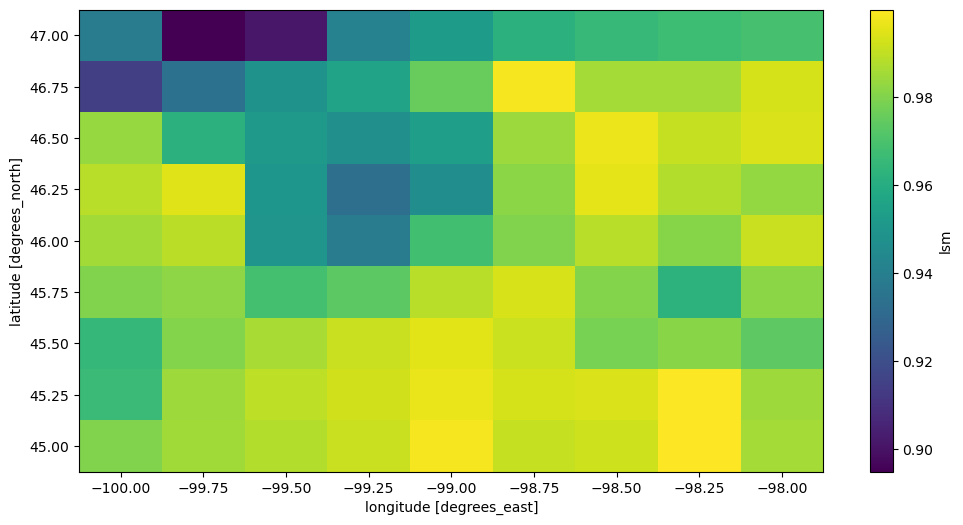

In [137]:
plt.figure(figsize=(12,6))
ds.lsm.sel(lat=slice(47,45),lon=slice(-100,-98)).plot()

In [148]:
test_lat=33
test_lon = -10

ds.lsm.sel(lat=slice(np.min([test_lat+res, float(ds.lsm.lat[0])]),
                             np.max([test_lat-res, float(ds.lsm.lat[-1])])), 
                   lon=slice(np.max([lest_lon-res, float(ds.lsm.lon[0])]),
                             np.min([lest_lon+res, float(ds.lsm.lon[-1])])))

<xarray.DataArray 'lsm' (lat: 3, lon: 3)> Size: 72B
array([[0.999786, 0.99968 , 0.993438],
       [0.998718, 0.996796, 0.984573],
       [0.993637, 0.973174, 0.971495]])
Coordinates:
  * lat      (lat) float32 12B 33.25 33.0 32.75
  * lon      (lon) float32 12B -99.25 -99.0 -98.75